Objective: Classification: Survived (Yes/No)
Success Criteria: Accuracy > 80%
Constraints: Limited features, missing values, imbalanced classes
Data shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
   survived  pclass   age  sibsp  parch     fare    w

/tmp/ipykernel_1322/391124375.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_1322/391124375.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

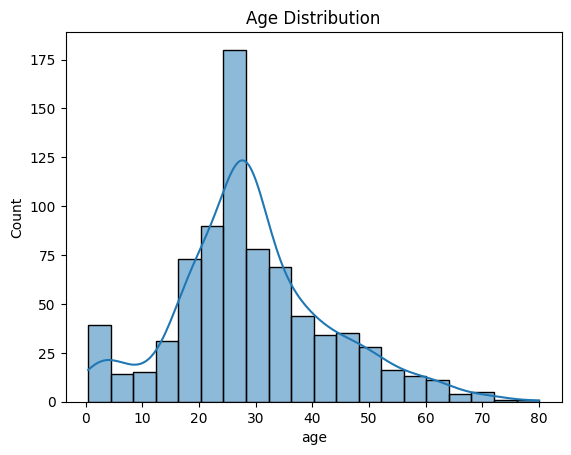

ValueError: could not convert string to float: 'C'

In [3]:
# Define the problem:
# Predict whether a passenger survived the Titanic disaster based on features.
objective = "Classification: Survived (Yes/No)"
success_criteria = "Accuracy > 80%"
constraints = "Limited features, missing values, imbalanced classes"
print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)
#      2️⃣ Data Collection
import pandas as pd                 # Load dataset (Titanic dataset from seaborn or CSV)
import seaborn as sns
df = sns.load_dataset("titanic")
print("Data shape:", df.shape)
print(df.head())
#3️⃣ Data Cleaning & Preprocessing
# Handle missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
# Drop duplicates
df.drop_duplicates(inplace=True)
# Encode categorical variables
df = pd.get_dummies(df, columns=['sex','class','embarked'], drop_first=True)
# Feature engineering: family size
df['family_size'] = df['sibsp'] + df['parch']
print(df.head())
#Exploratory Data Analysis (EDA)
#python
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of age
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Correlation matrix
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#5️⃣ Data Modeling
#python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Define features and target
X = df.drop(columns=['survived'])
y = df['survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
#6️⃣ Model Evaluation
#python
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
